## QM9: GAT vs GATv2 (multi-target)

This notebook compares custom sparse QM9 versions of GAT and GATv2 on selected QM9 molecular-property targets.

### Goals

- Train both models with the same data split and optimization setup.
- Use edge-aware message passing suitable for molecular graphs.
- Evaluate target-wise performance with clear, labeled plots.

### Properties shown in this run

Targets are configured in `selected_target_ids` and mapped to labels (for example `mu`, `alpha`, `HOMO`).

In [26]:
import torch
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from copy import deepcopy
import importlib.util
import os


In [27]:
# Load models directly from src/models.py
path_to_models = os.path.abspath(os.path.join('..', 'src', 'models.py'))
spec = importlib.util.spec_from_file_location("models_direct", path_to_models)
models_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(models_module)

QM9_GAT_Model = models_module.QM9_GAT_Model
QM9_GATv2_Model = models_module.QM9_GATv2_Model
print("✅ Loaded QM9_GAT_Model + QM9_GATv2_Model from src/models.py")

✅ Loaded QM9_GAT_Model + QM9_GATv2_Model from src/models.py


## Dataset, targets, and normalization

- Uses a reproducible 2k subset of QM9 for quick iteration.
- Splits into train/validation/test.
- Supports multiple selected targets.
- Computes train-set mean/std per target and stores normalized labels (`y_norm`) for stable optimization.
- Reports MAE back in original target units for interpretability.

In [28]:
# 1) Load QM9
root_dir = os.path.join(os.getcwd(), '..', 'data', 'QM9')
full_dataset = QM9(root=root_dir)

# QM9 target names used in the paper's QM9 table order
qm9_target_names = [
    "mu", "alpha", "HOMO", "LUMO", "gap", "R2", "ZPVE",
    "U0", "U", "H", "G", "Cv", "Omega"
]

# Choose one or more targets (indices in the list above)
selected_target_ids = [0, 1, 2]  # e.g., mu, alpha, HOMO
num_targets = len(selected_target_ids)
target_labels = [qm9_target_names[i] if i < len(qm9_target_names) else f"target_{i}" for i in selected_target_ids]

# 2) Use a 2k subset for faster experimentation
torch.manual_seed(42)
subset_size = 6000
subset_indices = torch.randperm(len(full_dataset))[:subset_size]
subset = [full_dataset[int(i)] for i in subset_indices]

# 3) Split into train/val/test = 1600/200/200
num_train = 4000
num_val = 1000
train_raw = subset[:num_train]
val_raw = subset[num_train:num_train + num_val]
test_raw = subset[num_train + num_val:]

# 4) Normalize selected targets using train statistics only
train_targets = torch.stack([d.y[0, selected_target_ids] for d in train_raw]).float()
target_mean = train_targets.mean(dim=0)
target_std = train_targets.std(dim=0).clamp_min(1e-8)

def normalize_split(split):
    out = []
    for d in split:
        d2 = d.clone()
        d2.y_norm = ((d.y[:, selected_target_ids] - target_mean) / target_std).float()
        out.append(d2)
    return out

train_set = normalize_split(train_raw)
val_set = normalize_split(val_raw)
test_set = normalize_split(test_raw)

# 5) DataLoaders
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

edge_dim = train_set[0].edge_attr.size(-1) if getattr(train_set[0], 'edge_attr', None) is not None else None

print(f"Data location: {os.path.abspath(root_dir)}")
print(f"Subset: {subset_size} | Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Targets: {selected_target_ids} -> {target_labels}")
for i, name in enumerate(target_labels):
    print(f"  {name:<6} mean={target_mean[i].item():.4f} | std={target_std[i].item():.4f}")
print(f"Edge feature dim: {edge_dim}")

Data location: /Users/kilroyhere/Projects/gat-wrecked/data/QM9
Subset: 6000 | Train: 4000 | Val: 1000 | Test: 1000
Targets: [0, 1, 2] -> ['mu', 'alpha', 'HOMO']
  mu     mean=2.6328 | std=1.4245
  alpha  mean=75.4301 | std=8.1796
  HOMO   mean=-6.5389 | std=0.5997
Edge feature dim: 4


## Model source

`QM9_GAT_Model` and `QM9_GATv2_Model` are loaded from `src/models.py`.

Both are sparse, edge-aware QM9 variants designed for this notebook, so the architecture logic stays centralized in one place.

In [29]:
# GAT and GATv2 QM9 models are loaded from src/models.py.

## Training and evaluation utilities

These helper functions:

- train one epoch with L1 loss on normalized targets,
- denormalize predictions for reporting MAE in original units,
- track both mean MAE and per-target MAE,
- implement patience-based early stopping.

In [30]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data.x, data.edge_index, data.batch, edge_attr=data.edge_attr)
        loss = F.l1_loss(pred, data.y_norm)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_mae(model, loader, device, mean, std, target_ids):
    model.eval()
    num_t = len(target_ids)
    total_abs = torch.zeros(num_t, device=device)
    total_graphs = 0

    for data in loader:
        data = data.to(device)
        pred_norm = model(data.x, data.edge_index, data.batch, edge_attr=data.edge_attr)
        pred = pred_norm * std + mean
        true = data.y[:, target_ids]

        total_abs += (pred - true).abs().sum(dim=0)
        total_graphs += data.num_graphs

    per_target_mae = (total_abs / total_graphs).detach().cpu().tolist()
    mean_mae = float(sum(per_target_mae) / len(per_target_mae))
    return mean_mae, per_target_mae


def fit_with_early_stopping(model, train_loader, val_loader, test_loader, device,
                            mean, std, target_ids, epochs=200, lr=1e-3, weight_decay=0.0, patience=20):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val = float('inf')
    best_state = None
    wait = 0

    hist_val, hist_test = [], []
    hist_val_targets, hist_test_targets = [], []

    for epoch in range(1, epochs + 1):
        _ = train_epoch(model, train_loader, optimizer, device)
        val_mean_mae, val_targets = evaluate_mae(model, val_loader, device, mean, std, target_ids)
        test_mean_mae, test_targets = evaluate_mae(model, test_loader, device, mean, std, target_ids)

        hist_val.append(val_mean_mae)
        hist_test.append(test_mean_mae)
        hist_val_targets.append(val_targets)
        hist_test_targets.append(test_targets)

        if val_mean_mae < best_val:
            best_val = val_mean_mae
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Val mean MAE: {val_mean_mae:.4f} | Test mean MAE: {test_mean_mae:.4f}")

        if wait >= patience:
            print(f"Early stopping at epoch {epoch} (best val mean MAE={best_val:.4f})")
            break

    model.load_state_dict(best_state)
    best_val_mean, best_val_targets = evaluate_mae(model, val_loader, device, mean, std, target_ids)
    best_test_mean, best_test_targets = evaluate_mae(model, test_loader, device, mean, std, target_ids)
    return (
        hist_val, hist_test,
        hist_val_targets, hist_test_targets,
        best_val_mean, best_test_mean,
        best_val_targets, best_test_targets,
    )

In [31]:
# Evaluation utilities are defined in the previous cell (evaluate_mae / fit_with_early_stopping).

## Train both models with early stopping

- Both models are trained on normalized targets.
- Early stopping monitors validation **mean MAE** across selected targets.
- After training, the best checkpoint is restored and final validation/test metrics are reported.

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Keep GAT as baseline
gat_hidden_dim = 64
gat_nheads = 4
gat_epochs = 200
gat_lr = 1e-3
gat_patience = 20

# Tune GATv2 separately + increase capacity
gatv2_hidden_dim = 128
gatv2_nheads = 8
gatv2_epochs = 300
gatv2_lr = 5e-4
gatv2_patience = 40

# GAT baseline from src/models.py (custom sparse + edge_attr)
model_gat = QM9_GAT_Model(
    nfeat=train_set[0].x.size(-1),
    nhid=gat_hidden_dim,
    nclass=num_targets,
    nheads=gat_nheads,
    dropout=0.1,
    alpha=0.2,
    edge_dim=edge_dim,
).to(device)

# GATv2 from src/models.py (custom sparse + edge_attr)
model_v2 = QM9_GATv2_Model(
    nfeat=train_set[0].x.size(-1),
    nhid=gatv2_hidden_dim,
    nclass=num_targets,
    nheads=gatv2_nheads,
    dropout=0.1,
    alpha=0.2,
    edge_dim=edge_dim,
).to(device)

mean_dev = target_mean.to(device)
std_dev = target_std.to(device)

print("Training GAT...")
print(f"  config: hidden={gat_hidden_dim}, heads={gat_nheads}, lr={gat_lr}, epochs={gat_epochs}, patience={gat_patience}")
(
    gat_val_history, gat_history,
    gat_val_targets_history, gat_test_targets_history,
    gat_best_val, gat_best_test,
    gat_best_val_targets, gat_best_test_targets,
) = fit_with_early_stopping(
    model_gat, train_loader, val_loader, test_loader, device,
    mean=mean_dev, std=std_dev, target_ids=selected_target_ids,
    epochs=gat_epochs, lr=gat_lr, patience=gat_patience,
)

print("\nTraining GATv2...")
print(f"  config: hidden={gatv2_hidden_dim}, heads={gatv2_nheads}, lr={gatv2_lr}, epochs={gatv2_epochs}, patience={gatv2_patience}")
(
    v2_val_history, v2_history,
    v2_val_targets_history, v2_test_targets_history,
    v2_best_val, v2_best_test,
    v2_best_val_targets, v2_best_test_targets,
) = fit_with_early_stopping(
    model_v2, train_loader, val_loader, test_loader, device,
    mean=mean_dev, std=std_dev, target_ids=selected_target_ids,
    epochs=gatv2_epochs, lr=gatv2_lr, patience=gatv2_patience,
)

print(f"\nBest mean Val/Test MAE | GAT: {gat_best_val:.4f}/{gat_best_test:.4f} | GATv2: {v2_best_val:.4f}/{v2_best_test:.4f}")
print("\nPer-target Test MAE:")
for i, name in enumerate(target_labels):
    print(f"  {name:<6} | GAT: {gat_best_test_targets[i]:.4f} | GATv2: {v2_best_test_targets[i]:.4f}")

Training GAT...
  config: hidden=64, heads=4, lr=0.001, epochs=200, patience=20
Epoch 010 | Val mean MAE: 1.6516 | Test mean MAE: 1.7355
Epoch 020 | Val mean MAE: 1.6040 | Test mean MAE: 1.7020
Epoch 030 | Val mean MAE: 1.5195 | Test mean MAE: 1.5879
Epoch 040 | Val mean MAE: 1.5101 | Test mean MAE: 1.5924
Epoch 050 | Val mean MAE: 1.4542 | Test mean MAE: 1.5243
Epoch 060 | Val mean MAE: 1.5282 | Test mean MAE: 1.6234
Epoch 070 | Val mean MAE: 1.4965 | Test mean MAE: 1.5613
Early stopping at epoch 70 (best val mean MAE=1.4542)

Training GATv2...
  config: hidden=128, heads=8, lr=0.0005, epochs=300, patience=40
Epoch 010 | Val mean MAE: 1.7631 | Test mean MAE: 1.8666
Epoch 020 | Val mean MAE: 1.6288 | Test mean MAE: 1.7204
Epoch 030 | Val mean MAE: 1.6891 | Test mean MAE: 1.7876
Epoch 040 | Val mean MAE: 1.7456 | Test mean MAE: 1.8398
Epoch 050 | Val mean MAE: 1.7826 | Test mean MAE: 1.8694
Epoch 060 | Val mean MAE: 1.6524 | Test mean MAE: 1.7386
Epoch 070 | Val mean MAE: 1.4121 | Test 

## Per-target learning curves

This section plots separate line charts for each selected QM9 target (for example `mu`, `alpha`, and `HOMO`) so you can compare how GAT and GATv2 learn each property over epochs.

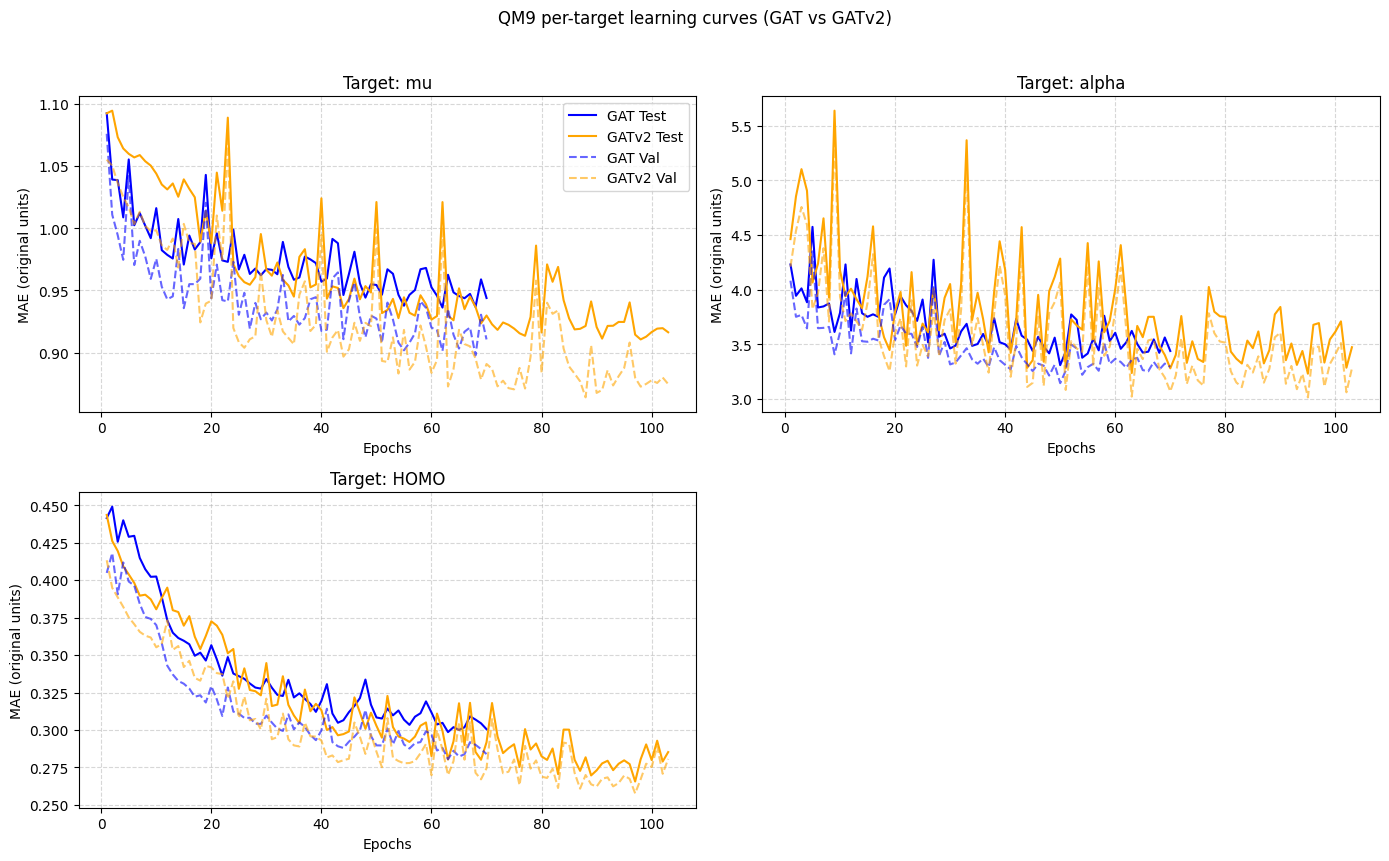

In [33]:
import math

num_t = len(target_labels)
cols = 2
rows = math.ceil(num_t / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 4.2 * rows), squeeze=False)

for i, name in enumerate(target_labels):
    r, c = divmod(i, cols)
    ax = axes[r][c]

    gat_val_t = [row[i] for row in gat_val_targets_history]
    gat_test_t = [row[i] for row in gat_test_targets_history]
    v2_val_t = [row[i] for row in v2_val_targets_history]
    v2_test_t = [row[i] for row in v2_test_targets_history]

    ax.plot(range(1, len(gat_test_t) + 1), gat_test_t, label='GAT Test', color='blue')
    ax.plot(range(1, len(v2_test_t) + 1), v2_test_t, label='GATv2 Test', color='orange')
    ax.plot(range(1, len(gat_val_t) + 1), gat_val_t, '--', label='GAT Val', color='blue', alpha=0.6)
    ax.plot(range(1, len(v2_val_t) + 1), v2_val_t, '--', label='GATv2 Val', color='orange', alpha=0.6)

    ax.set_title(f"Target: {name}")
    ax.set_xlabel('Epochs')
    ax.set_ylabel('MAE (original units)')
    ax.grid(True, linestyle='--', alpha=0.5)

    if i == 0:
        ax.legend()

# Hide any unused subplot slots
for j in range(num_t, rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis('off')

plt.suptitle('QM9 per-target learning curves (GAT vs GATv2)', y=1.02)
plt.tight_layout()
plt.show()

## Notes on interpreting results

- Lower MAE is better.
- Dashed curves are validation; solid curves are test.
- If validation improves but test does not, that can indicate overfitting to this small subset.
- For a paper-faithful benchmark, increase data size and evaluate all 13 QM9 targets with multiple random seeds.